# 🤖 Classification — Phân loại AQI 6 mức | Hà Nội 2022–2025
> **Pipeline:** Random Forest → XGBoost  
> **Xử lý mất cân bằng:** SMOTE (Good 3.4%, Hazardous 0.6%)  
> **Đánh giá:** F1-macro · ROC-AUC · Confusion Matrix từng class  
> **Output:** File `xgboost_best_model.pkl` để Linh Linh dùng cho SHAP

## 0. Import thư viện

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlepad': 10})

CAT_ORDER = ['Good', 'Moderate', 'Unhealthy for sensitive groups',
             'Unhealthy', 'Very Unhealthy', 'Hazardous']
PALETTE = {
    'Good':                           '#2ecc71',
    'Moderate':                       '#f1c40f',
    'Unhealthy for sensitive groups': '#e67e22',
    'Unhealthy':                      '#e74c3c',
    'Very Unhealthy':                 '#9b59b6',
    'Hazardous':                      '#7f1d1d',
}
print("✅ Import xong!")

✅ Import xong!


## 1. Đọc dữ liệu & chuẩn bị features

In [2]:
DATA_PATH = os.path.join('..', 'clean', 'hanoi_aqi_cleaned.csv')
df = pd.read_csv(DATA_PATH)

FEAT_COLS = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2',
             'clouds', 'precipitation', 'pressure', 'relative_humidity',
             'temperature', 'uv_index', 'wind_speed',
             'hour', 'month', 'season', 'is_weekend', 'is_rush_hour', 'day_of_week']

X  = df[FEAT_COLS].fillna(df[FEAT_COLS].median())
le = LabelEncoder()
le.fit(CAT_ORDER)
y  = le.transform(df['aqi_category'])

print(f"Shape X: {X.shape}")
print(f"Features ({len(FEAT_COLS)}): {FEAT_COLS}")
print(f"Classes: {list(le.classes_)}")
print()
print("Phân bố class:")
for cls, cnt in zip(le.classes_, np.bincount(y)):
    bar = '█' * int(cnt / len(y) * 40)
    print(f"  {cls:<38}: {cnt:>6,} ({cnt/len(y)*100:5.1f}%)  {bar}")

Shape X: (30341, 19)
Features (19): ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 'precipitation', 'pressure', 'relative_humidity', 'temperature', 'uv_index', 'wind_speed', 'hour', 'month', 'season', 'is_weekend', 'is_rush_hour', 'day_of_week']
Classes: [np.str_('Good'), np.str_('Hazardous'), np.str_('Moderate'), np.str_('Unhealthy'), np.str_('Unhealthy for sensitive groups'), np.str_('Very Unhealthy')]

Phân bố class:
  Good                                  :  1,029 (  3.4%)  █
  Hazardous                             :    173 (  0.6%)  
  Moderate                              : 11,682 ( 38.5%)  ███████████████
  Unhealthy                             :  6,372 ( 21.0%)  ████████
  Unhealthy for sensitive groups        :  8,440 ( 27.8%)  ███████████
  Very Unhealthy                        :  2,645 (  8.7%)  ███


## 2. Chia tập Train/Test theo thời gian & SMOTE
**Chiến lược chia dữ liệu theo thời gian** (không random) — phản ánh đúng thực tế dự báo:
- **Train:** 2022 – 2024 (~25,996 mẫu)  
- **Test:** 2025 (~4,345 mẫu)

**SMOTE** chỉ áp dụng trên tập train để xử lý mất cân bằng (Good 3.4%, Hazardous 0.6%)

In [3]:
## ── Chia tập theo thời gian: Train=2022–2024, Test=2025 ──────────────────
mask_train = df['year'].isin([2022, 2023, 2024])
mask_test  = df['year'] == 2025

X_train_raw = X[mask_train]
X_test      = X[mask_test]
y_train_raw = y[mask_train]
y_test      = y[mask_test]

print(f"Train (2022–2024): {len(X_train_raw):,} mẫu")
print(f"Test  (2025)     : {len(X_test):,} mẫu")
print()

# Phân bố class trong tập test
print("Phân bố class trong tập Test (2025):")
for cls, cnt in zip(le.classes_, np.bincount(y_test)):
    bar = '█' * int(cnt / len(y_test) * 30)
    print(f"  {cls:<38}: {cnt:>5,} ({cnt/len(y_test)*100:5.1f}%)  {bar}")
print()

# SMOTE chỉ trên tập train
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train_raw, y_train_raw)

print("Phân bố sau SMOTE (train 2022–2024):")
after = pd.Series(y_train_sm).value_counts().sort_index()
for idx, cnt in after.items():
    bar = '█' * int(cnt / len(y_train_sm) * 30)
    print(f"  {le.classes_[idx]:<38}: {cnt:>6,}  {bar}")
print(f"\nTổng train sau SMOTE: {len(X_train_sm):,}")

# y_bin dùng cho ROC-AUC
y_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))

Train (2022–2024): 25,996 mẫu
Test  (2025)     : 4,345 mẫu

Phân bố class trong tập Test (2025):
  Good                                  :    27 (  0.6%)  
  Hazardous                             :     6 (  0.1%)  
  Moderate                              : 1,060 ( 24.4%)  ███████
  Unhealthy                             : 1,163 ( 26.8%)  ████████
  Unhealthy for sensitive groups        : 1,483 ( 34.1%)  ██████████
  Very Unhealthy                        :   606 ( 13.9%)  ████

Phân bố sau SMOTE (train 2022–2024):
  Good                                  : 10,622  █████
  Hazardous                             : 10,622  █████
  Moderate                              : 10,622  █████
  Unhealthy                             : 10,622  █████
  Unhealthy for sensitive groups        : 10,622  █████
  Very Unhealthy                        : 10,622  █████

Tổng train sau SMOTE: 63,732


## 3. Random Forest
Model baseline mạnh — không cần scale, robust với outliers.

In [4]:
print("Training Random Forest (n_estimators=200)...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)
y_bin     = label_binarize(y_test, classes=np.arange(len(le.classes_)))

f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
auc_rf = roc_auc_score(y_bin, y_prob_rf, average='macro', multi_class='ovr')

print(f"\n✅ Random Forest:")
print(f"   F1-macro  = {f1_rf:.4f}")
print(f"   ROC-AUC   = {auc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, digits=4))

Training Random Forest (n_estimators=200)...

✅ Random Forest:
   F1-macro  = 0.9236
   ROC-AUC   = 0.9995

                                precision    recall  f1-score   support

                          Good     0.8438    1.0000    0.9153        27
                     Hazardous     1.0000    0.5000    0.6667         6
                      Moderate     0.9962    0.9934    0.9948      1060
                     Unhealthy     0.9888    0.9862    0.9875      1163
Unhealthy for sensitive groups     0.9973    0.9912    0.9943      1483
                Very Unhealthy     0.9725    0.9934    0.9829       606

                      accuracy                         0.9901      4345
                     macro avg     0.9664    0.9107    0.9236      4345
                  weighted avg     0.9903    0.9901    0.9901      4345



## 4. XGBoost
Gradient boosting — thường vượt RF trên tabular data có class imbalance.

In [5]:
print("Training XGBoost (n_estimators=300)...")
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    eval_metric='mlogloss', random_state=42,
    n_jobs=-1, verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)

f1_xgb  = f1_score(y_test, y_pred_xgb, average='macro')
auc_xgb = roc_auc_score(y_bin, y_prob_xgb, average='macro', multi_class='ovr')

print(f"\n✅ XGBoost:")
print(f"   F1-macro  = {f1_xgb:.4f}")
print(f"   ROC-AUC   = {auc_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_, digits=4))

Training XGBoost (n_estimators=300)...

✅ XGBoost:
   F1-macro  = 0.9781
   ROC-AUC   = 0.9997

                                precision    recall  f1-score   support

                          Good     1.0000    1.0000    1.0000        27
                     Hazardous     0.8571    1.0000    0.9231         6
                      Moderate     0.9934    0.9868    0.9901      1060
                     Unhealthy     0.9764    0.9966    0.9864      1163
Unhealthy for sensitive groups     0.9899    0.9906    0.9902      1483
                Very Unhealthy     0.9949    0.9637    0.9790       606

                      accuracy                         0.9876      4345
                     macro avg     0.9686    0.9896    0.9781      4345
                  weighted avg     0.9877    0.9876    0.9876      4345



## 5. Lưu best model XGBoost (cho Linh Linh dùng SHAP)

In [6]:
# Xác định best model theo F1-macro
best_name  = 'XGBoost' if f1_xgb >= f1_rf else 'Random Forest'
best_model = xgb if f1_xgb >= f1_rf else rf
print(f"Best model: {best_name}  (F1-macro={max(f1_xgb,f1_rf):.4f})")

bundle = {
    'model':         best_model,
    'label_encoder': le,
    'features':      FEAT_COLS,
}
joblib.dump(bundle, 'xgboost_best_model.pkl')
print("✅ Đã lưu: xgboost_best_model.pkl")
print()
print("Cách Linh Linh load model để dùng SHAP:")
print("""
  import joblib, shap
  bundle = joblib.load('xgboost_best_model.pkl')
  model  = bundle['model']
  feats  = bundle['features']
  explainer = shap.TreeExplainer(model)
  shap_values = explainer.shap_values(X_test[feats])
""")

Best model: XGBoost  (F1-macro=0.9781)
✅ Đã lưu: xgboost_best_model.pkl

Cách Linh Linh load model để dùng SHAP:

  import joblib, shap
  bundle = joblib.load('xgboost_best_model.pkl')
  model  = bundle['model']
  feats  = bundle['features']
  explainer = shap.TreeExplainer(model)
  shap_values = explainer.shap_values(X_test[feats])



## 6. Bảng so sánh Random Forest vs XGBoost

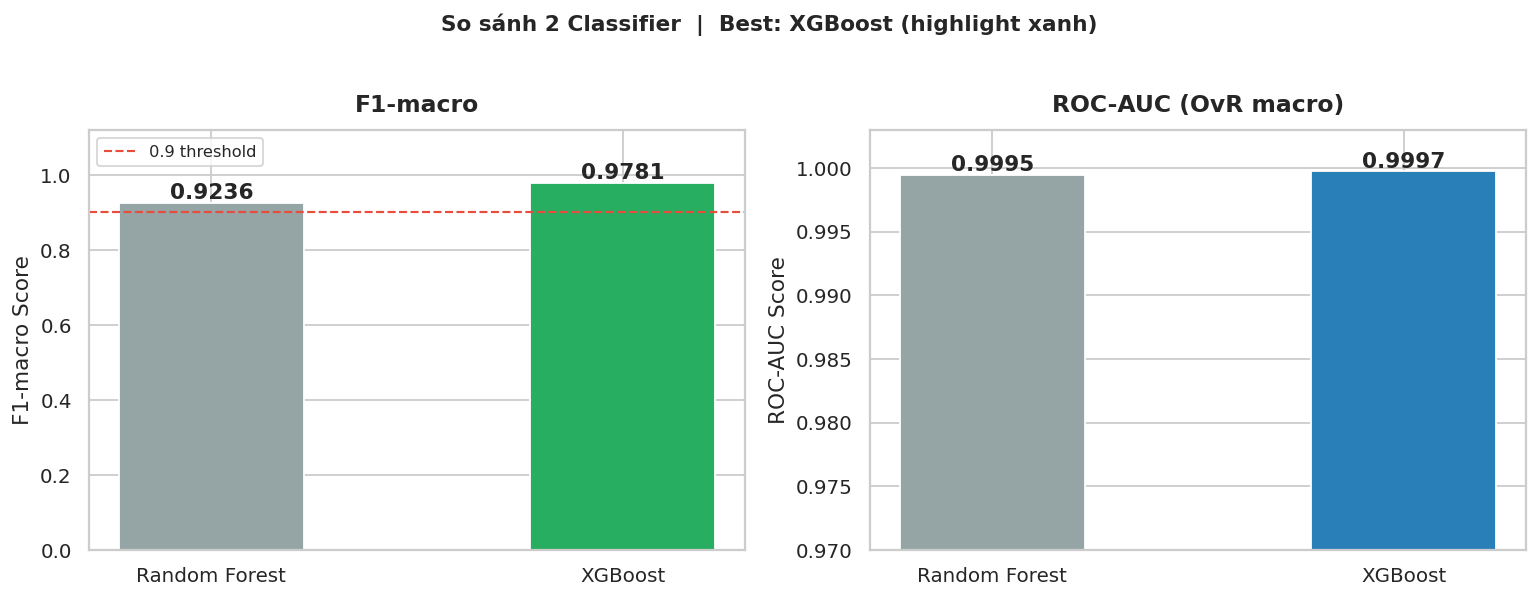

Model                  F1-macro    ROC-AUC
------------------------------------------
Random Forest            0.9236     0.9995
XGBoost                  0.9781     0.9997 ← BEST


In [7]:
models     = ['Random Forest', 'XGBoost']
f1s        = [f1_rf,  f1_xgb]
aucs       = [auc_rf, auc_xgb]
best_idx   = int(np.argmax(f1s))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bar_colors_f1  = ['#95a5a6', '#95a5a6']
bar_colors_auc = ['#95a5a6', '#95a5a6']
bar_colors_f1[best_idx]  = '#27ae60'
bar_colors_auc[best_idx] = '#2980b9'

# F1-macro
b1 = axes[0].bar(models, f1s, color=bar_colors_f1, edgecolor='white', width=0.45)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('F1-macro Score', fontsize=12)
axes[0].set_title('F1-macro', fontsize=13, fontweight='bold')
axes[0].axhline(0.9, ls='--', color='#e74c3c', lw=1.2, label='0.9 threshold')
axes[0].legend(fontsize=9)
for bar, v in zip(b1, f1s):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# ROC-AUC
b2 = axes[1].bar(models, aucs, color=bar_colors_auc, edgecolor='white', width=0.45)
axes[1].set_ylim(0.97, 1.003)
axes[1].set_ylabel('ROC-AUC Score', fontsize=12)
axes[1].set_title('ROC-AUC (OvR macro)', fontsize=13, fontweight='bold')
for bar, v in zip(b2, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

fig.suptitle(f'So sánh 2 Classifier  |  Best: {models[best_idx]} (highlight xanh)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"{'Model':<20} {'F1-macro':>10} {'ROC-AUC':>10}")
print("-"*42)
for m, f1, auc in zip(models, f1s, aucs):
    flag = " ← BEST" if f1 == max(f1s) else ""
    print(f"{m:<20} {f1:>10.4f} {auc:>10.4f}{flag}")

## 7. F1-score từng class — RF vs XGBoost

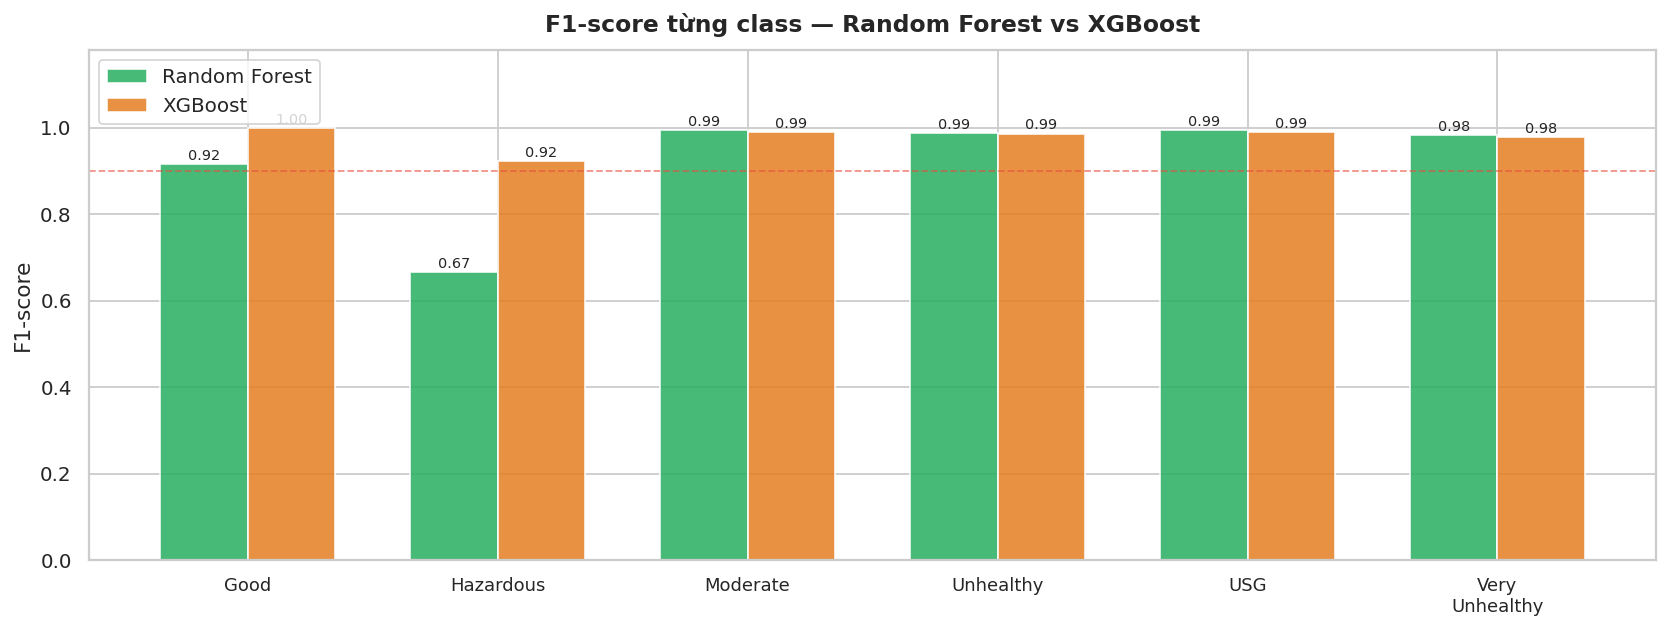

In [8]:
short_labels = ['Good', 'Hazardous', 'Moderate', 'Unhealthy', 'USG', 'Very\nUnhealthy']
x = np.arange(len(le.classes_))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
for i, (mname, pred) in enumerate([('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]):
    report   = classification_report(y_test, pred, output_dict=True, zero_division=0)
    f1_per   = [report[str(k)]['f1-score'] for k in range(len(le.classes_))]
    clr      = ['#27ae60', '#e67e22'][i]
    bars     = ax.bar(x + i*w, f1_per, w, label=mname, color=clr,
                      alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, f1_per):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.2f}', ha='center', fontsize=8)

ax.set_xticks(x + w/2)
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('F1-score từng class — Random Forest vs XGBoost', fontsize=13, fontweight='bold')
ax.axhline(0.9, ls='--', color='#e74c3c', lw=1, alpha=0.6)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix trực quan từng class

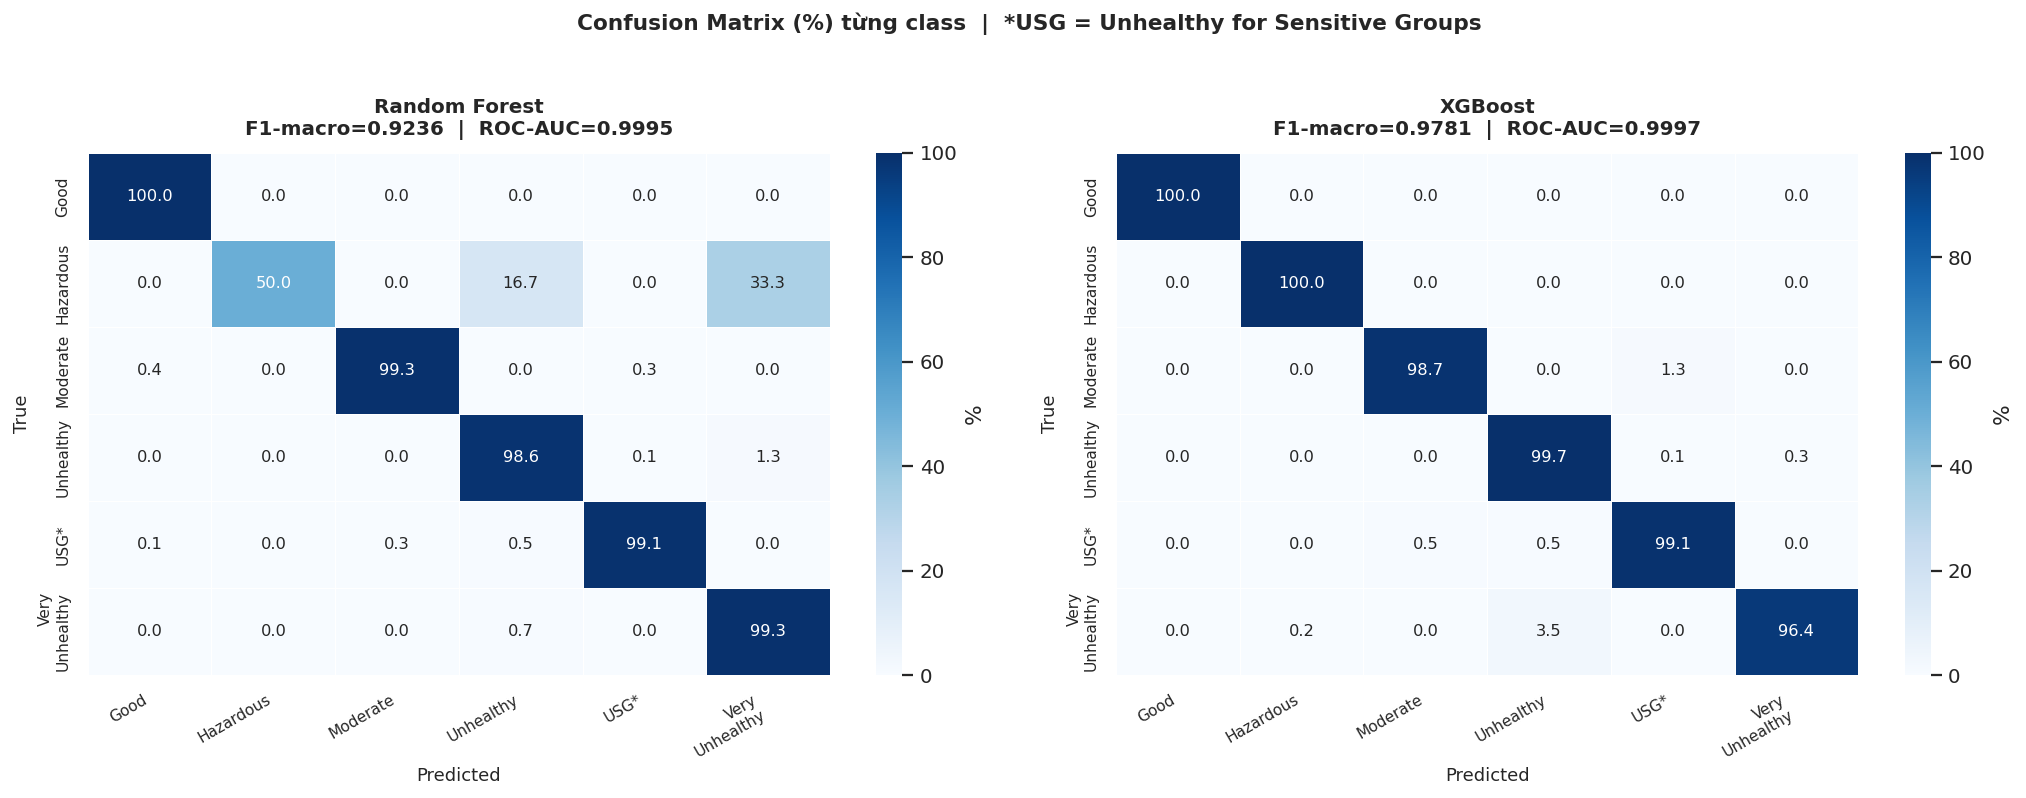

In [9]:
cm_labels = ['Good', 'Hazardous', 'Moderate', 'Unhealthy', 'USG*', 'Very\nUnhealthy']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (mname, pred, f1, auc) in zip(axes, [
    ('Random Forest', y_pred_rf,  f1_rf,  auc_rf),
    ('XGBoost',       y_pred_xgb, f1_xgb, auc_xgb),
]):
    cm     = confusion_matrix(y_test, pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=cm_labels, yticklabels=cm_labels,
                linewidths=0.5, cbar_kws={'label': '%'}, ax=ax,
                annot_kws={'size': 9})
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=8.5, rotation=30, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8.5)
    ax.set_title(f'{mname}\nF1-macro={f1:.4f}  |  ROC-AUC={auc:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

fig.suptitle('Confusion Matrix (%) từng class  |  *USG = Unhealthy for Sensitive Groups',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Feature Importance — XGBoost

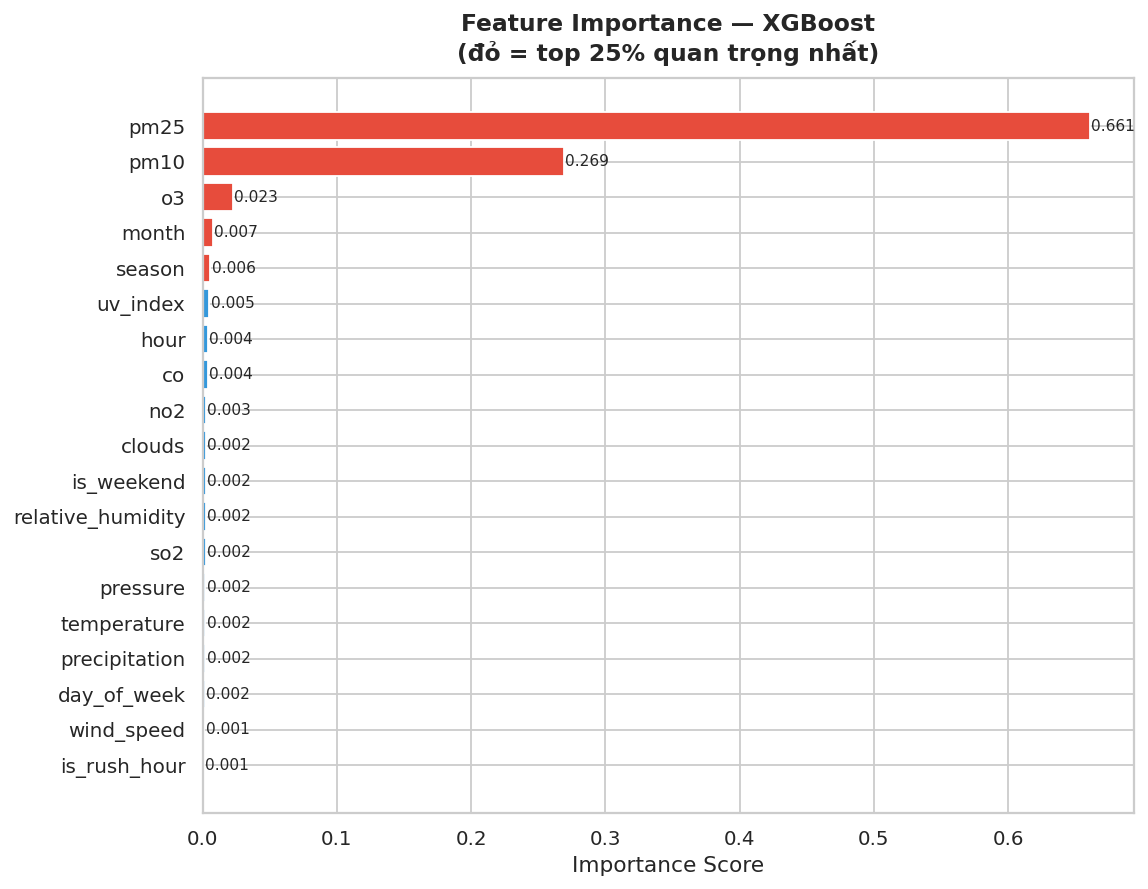

Top 5 features quan trọng nhất (XGBoost):
  pm25                  : 0.6609
  pm10                  : 0.2692
  o3                    : 0.0225
  month                 : 0.0074
  season                : 0.0057


In [10]:
importances = pd.Series(xgb.feature_importances_, index=FEAT_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if v >= importances.quantile(0.75) else '#3498db' for v in importances]
bars   = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance — XGBoost\n(đỏ = top 25% quan trọng nhất)',
             fontsize=13, fontweight='bold')

for bar, v in zip(bars, importances.values):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

print("Top 5 features quan trọng nhất (XGBoost):")
for feat, val in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<22}: {val:.4f}")

## 10. Tổng kết kết quả

In [11]:
print("=" * 60)
print("  KẾT QUẢ CLASSIFICATION — HÀ NỘI AQI 2022–2025")
print("=" * 60)
print(f"  {'Model':<20} {'F1-macro':>10} {'ROC-AUC':>10}")
print("  " + "-"*42)
for m, f1, auc in zip(models, f1s, aucs):
    flag = "  ← BEST ✅" if f1 == max(f1s) else ""
    print(f"  {m:<20} {f1:>10.4f} {auc:>10.4f}{flag}")
print()
print(f"  File đã lưu: xgboost_best_model.pkl")
print(f"  Features:    {len(FEAT_COLS)} features ({', '.join(FEAT_COLS[:4])}...)")
print("=" * 60)

  KẾT QUẢ CLASSIFICATION — HÀ NỘI AQI 2022–2025
  Model                  F1-macro    ROC-AUC
  ------------------------------------------
  Random Forest            0.9236     0.9995
  XGBoost                  0.9781     0.9997  ← BEST ✅

  File đã lưu: xgboost_best_model.pkl
  Features:    19 features (co, no2, o3, pm10...)
